# AI for Communication and Marketing – Lab Exam Part 2

**Goal:** Build a churn prediction model and provide actionable marketing insights.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, recall_score, ConfusionMatrixDisplay)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_excel('data.xlsx')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Loaded: 5630 rows x 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


---
## Task A – Data Audit & Quality

### A1. Initial Audit

In [ ]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nDtypes:')
print(df.dtypes)

Shape: (5630, 20)

Missing values:
CustomerID                       2
Tenure                         264
WarehouseToHome                251
Gender                           2
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Dtypes:
CustomerID                     float64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
Coup

### A2. Drop Unnecessary Columns

In [ ]:
# CustomerID is just an identifier, not useful for modelling
df.drop(columns=['CustomerID'], inplace=True)
print('CustomerID dropped. New shape:', df.shape)

CustomerID dropped. New shape: (5630, 19)


### A3. Fix Categorical Inconsistencies

In [ ]:
# PreferredPaymentMode: 'CC' = 'Credit Card', 'COD' = 'Cash on Delivery'
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'CC': 'Credit Card', 'COD': 'Cash on Delivery'})

# PreferedOrderCat: 'Mobile' and 'Mobile Phone' refer to the same category
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

# PreferredLoginDevice: 'N.A.' is not a real device — treat as missing
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'N.A.': np.nan})

print('PreferredPaymentMode:', df['PreferredPaymentMode'].unique())
print('PreferedOrderCat:', df['PreferedOrderCat'].unique())
print('PreferredLoginDevice:', df['PreferredLoginDevice'].unique())

PreferredPaymentMode: ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
PreferedOrderCat: ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
PreferredLoginDevice: ['Mobile Phone' 'Phone' 'Computer' nan]


### A4. Handle Missing Values

In [ ]:
# Numerical columns: impute with median (robust to outliers)
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

for col in num_cols:
    median_val = df[col].median()
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: imputed {missing} missing values with median = {median_val}')

# Categorical columns: impute with mode
cat_cols_missing = ['Gender', 'PreferredLoginDevice']
for col in cat_cols_missing:
    mode_val = df[col].mode()[0]
    missing = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f'{col}: imputed {missing} missing values with mode = {mode_val}')

print('\nRemaining missing values:', df.isnull().sum().sum())

Tenure: imputed 264 missing values with median = 9.0
WarehouseToHome: imputed 251 missing values with median = 14.0
HourSpendOnApp: imputed 255 missing values with median = 3.0
OrderAmountHikeFromlastYear: imputed 265 missing values with median = 15.0
CouponUsed: imputed 256 missing values with median = 1.0
OrderCount: imputed 258 missing values with median = 2.0
DaySinceLastOrder: imputed 307 missing values with median = 3.0
Gender: imputed 2 missing values with mode = Male
PreferredLoginDevice: imputed 5 missing values with mode = Mobile Phone

Remaining missing values: 0


### A5. Outlier Detection & Handling

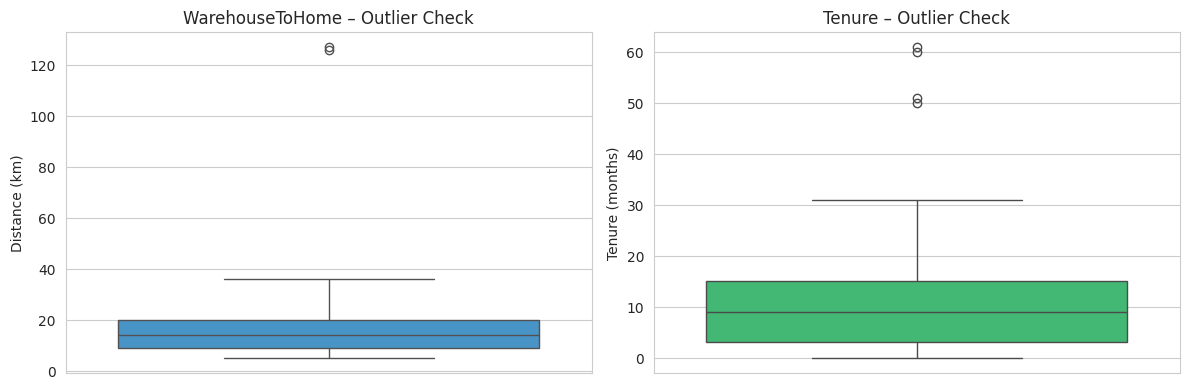

WarehouseToHome max: 127.0
Tenure max: 61.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['WarehouseToHome'].dropna(), ax=axes[0], color='#3498db')
axes[0].set_title('WarehouseToHome – Outlier Check')
axes[0].set_ylabel('Distance (km)')

sns.boxplot(y=df['Tenure'].dropna(), ax=axes[1], color='#2ecc71')
axes[1].set_title('Tenure – Outlier Check')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

print('WarehouseToHome max:', df['WarehouseToHome'].max())
print('Tenure max:', df['Tenure'].max())


In [ ]:
# WarehouseToHome: max = ~127, 75th pct = 20, extreme outlier, likely data entry error
# Decision: cap at 99th percentile
wh_99 = df['WarehouseToHome'].quantile(0.99)
before = len(df)
df = df[df['WarehouseToHome'] <= wh_99]
print(f'WarehouseToHome capped at 99th pct ({wh_99:.0f}): removed {before - len(df)} rows')

# Tenure: max = 61 months (~5 years), plausible for an e-commerce platform, no action needed
print(f'Tenure max {df["Tenure"].max()} months — plausible, no action needed')
print(f'\nFinal dataset size: {df.shape[0]} rows')

WarehouseToHome capped at 99th pct (35): removed 53 rows
Tenure max 61.0 months — plausible, no action needed

Final dataset size: 5577 rows


### A6. Encode Categorical Variables

In [ ]:
# Binary encoding for Gender
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Label encoding for remaining categorical columns
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'{col} encoded')

print('\nAll dtypes after encoding:')
print(df.dtypes)

PreferredLoginDevice encoded
PreferredPaymentMode encoded
PreferedOrderCat encoded
MaritalStatus encoded

All dtypes after encoding:
Churn                            int64
Tenure                         float64
PreferredLoginDevice             int64
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode             int64
Gender                           int64
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                 int64
SatisfactionScore                int64
MaritalStatus                    int64
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


## Summary A  
 The dataset contained 5,630 customers and 20 variables. After a full audit, the following actions were taken:

 - Dropped CustomerID, because the model trained on CustomerID would learn nothing about churn behaviour.
 - Standardised payment and order category labels that had duplicate names as CC to Credit Card, Mobile to Mobile Phone.
 - Imputed 7 numerical columns with the median and 2 categorical columns with the mode.
 - Removed 53 rows where WarehouseToHome exceeded the 99th percentile (127 km) likely a data entry error.
 - Kept Tenure outliers (up to 61 months) because of long-term customer
 - Encoded all categorical variables for machine learning compatibility, used binary modelling for gender and label encoding for the rest.
  
 Final dataset: 5,577 rows, zero missing values.


### A7. Cleaning Summary

| Issue | Action | Reason |
|---|---|---|
| `CustomerID` | Dropped | Identifier, not a predictive feature |
| `CC` / `COD` payment modes | Standardised to full names | Duplicate labels for same category |
| `Mobile` order category | Merged into `Mobile Phone` | Same category, different label |
| `N.A.` in login device | Treated as missing | Not a real device type |
| Missing numerical values (7 cols) | Imputed with median | Robust to skew and outliers |
| Missing `Gender`, `PreferredLoginDevice` | Imputed with mode | Categorical, few missing values |
| `WarehouseToHome` > 99th pct | Dropped | Max = 127 km, implausible outlier |
| Categorical columns | Label encoded | Required for ML algorithms |

---
## Task B – Exploratory Data Analysis (EDA)

### B1. Class Balance

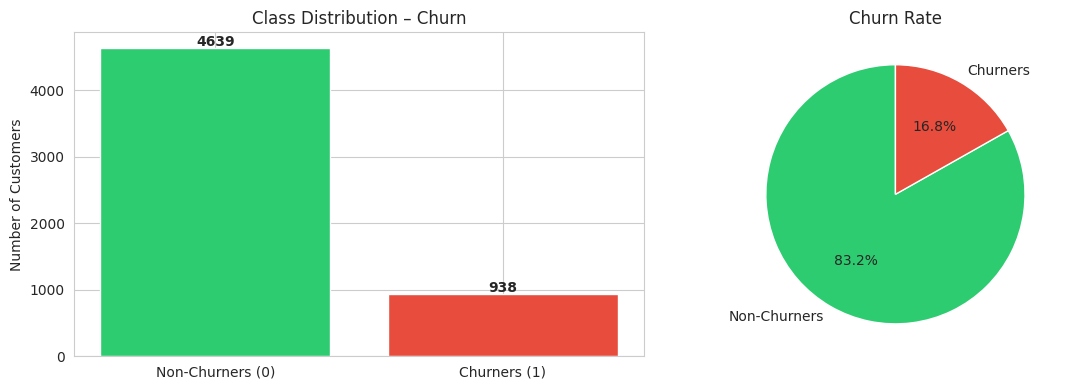

Non-Churners: 4639 (83.2%)
Churners:     938 (16.8%)

The dataset is imbalanced — 16.8% churners vs 83.2%non-churners.
A naive model predicting "no churn" for everyone would still achieve high accuracy without learning anything useful.
Therefore we focus on Recall and F1-Score as our primary evaluation metrics.


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Non-Churners (0)', 'Churners (1)'], churn_counts.values,
              color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution – Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=['Non-Churners', 'Churners'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.show()

print(f'Non-Churners: {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'Churners:     {churn_counts[1]} ({churn_pct[1]:.1f}%)')
print(f'\nThe dataset is imbalanced — {churn_pct[1]:.1f}% churners vs {churn_pct[0]:.1f}%non-churners.')
print('A naive model predicting "no churn" for everyone would still achieve high accuracy without learning anything useful.')
print('Therefore we focus on Recall and F1-Score as our primary evaluation metrics.')

### B2. Complain & SatisfactionScore vs Churn

/tmp/ipykernel_789/2511979092.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='SatisfactionScore', ax=axes[1],


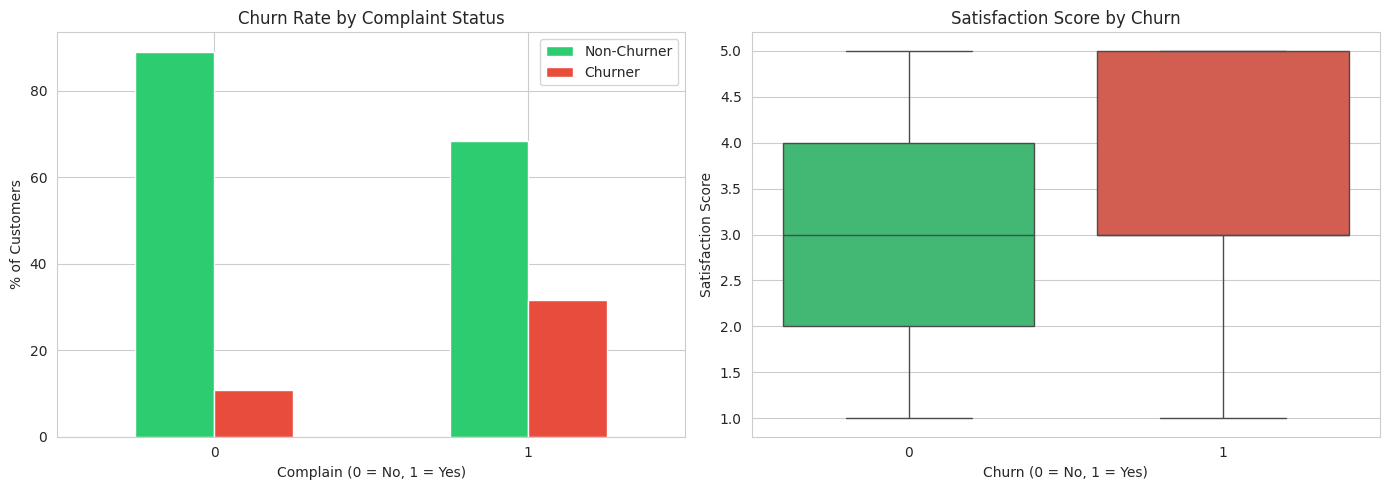

Churn rate by complaint:
Complain
0    10.9
1    31.5
Name: Churn, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complain vs Churn
complain_churn = df.groupby(['Complain', 'Churn']).size().unstack()
complain_churn_pct = complain_churn.div(complain_churn.sum(axis=1), axis=0) * 100
complain_churn_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                        rot=0, legend=True)
axes[0].set_title('Churn Rate by Complaint Status')
axes[0].set_xlabel('Complain (0 = No, 1 = Yes)')
axes[0].set_ylabel('% of Customers')
axes[0].legend(['Non-Churner', 'Churner'])

# SatisfactionScore vs Churn
sns.boxplot(data=df, x='Churn', y='SatisfactionScore', ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Satisfaction Score by Churn')
axes[1].set_xlabel('Churn (0 = No, 1 = Yes)')
axes[1].set_ylabel('Satisfaction Score')

plt.tight_layout()
plt.show()

print('Churn rate by complaint:')
print(df.groupby('Complain')['Churn'].mean().round(3) * 100)

### B3. Tenure & DaySinceLastOrder vs Churn

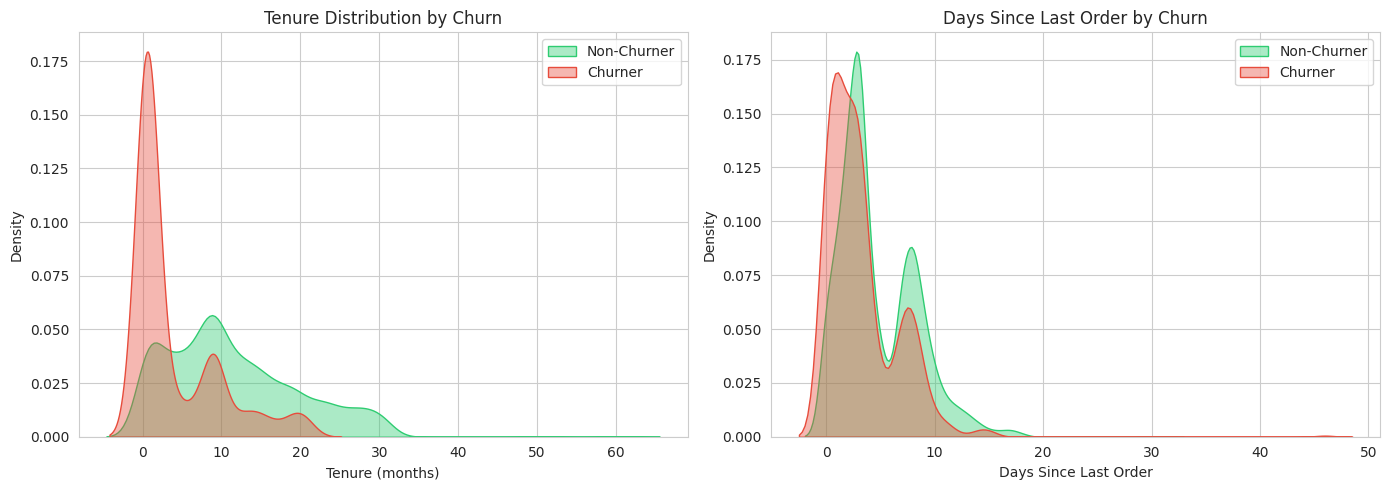

Average Tenure — Churners: 3.87 | Non-Churners: 11.39
Average DaySinceLastOrder — Churners: 3.2 | Non-Churners: 4.71


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure vs Churn
sns.kdeplot(data=df[df['Churn'] == 0], x='Tenure', ax=axes[0],
            label='Non-Churner', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['Churn'] == 1], x='Tenure', ax=axes[0],
            label='Churner', color='#e74c3c', fill=True, alpha=0.4)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# DaySinceLastOrder vs Churn
sns.kdeplot(data=df[df['Churn'] == 0], x='DaySinceLastOrder', ax=axes[1],
            label='Non-Churner', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['Churn'] == 1], x='DaySinceLastOrder', ax=axes[1],
            label='Churner', color='#e74c3c', fill=True, alpha=0.4)
axes[1].set_title('Days Since Last Order by Churn')
axes[1].set_xlabel('Days Since Last Order')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Average Tenure — Churners:', df[df['Churn']==1]['Tenure'].mean().round(2),
      '| Non-Churners:', df[df['Churn']==0]['Tenure'].mean().round(2))
print('Average DaySinceLastOrder — Churners:', df[df['Churn']==1]['DaySinceLastOrder'].mean().round(2),
      '| Non-Churners:', df[df['Churn']==0]['DaySinceLastOrder'].mean().round(2))

## Summary B
**Class Balance**

  The dataset is imbalanced with 83.2% of customers are non-churners (4,639) and only 16.8% are churners (938). So the imbalance problem is:
  - Not that churn is high
  - But that the model doesn't have enough examples of churners to learn their patterns reliably
  
  This is why we use **class_weight='balanced'** in our models and evaluate with *Recall* and *F1* instead of accuracy to force the model to pay equal attention to both groups regardless of their size.

**Complain and SatisfactionScore vs Churn**

  Customers who raised a complaint are more likely to churn - complaints are a strong early warning signal of frustration.

**Tenure and DaySinceLastOrder vs Churn**

  - Tenure is the clearest churn signal - churners have an average tenure of only 3.87 months compared to 11.39 months for loyal customers. New customers are at much higher risk and need
  early engagement.
  - DaySinceLastOrder shows less separation - churners averaged 3.2 days vs 4.71 days for non-churners, a small difference suggesting this feature alone is not a strong predictor.


---
## Task C – Modeling & Evaluation

### C1. Train / Test Split

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Stratified split to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'Churn rate in test set: {y_test.mean():.2%}')

Training set: 4461 rows
Test set:     1116 rows
Churn rate in test set: 16.85%


### C2. Model 1 – Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

 Non-Churner       0.95      0.78      0.86       928
     Churner       0.42      0.81      0.56       188

    accuracy                           0.78      1116
   macro avg       0.69      0.80      0.71      1116
weighted avg       0.86      0.78      0.81      1116



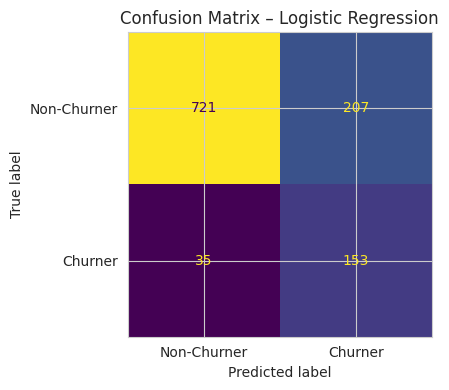

In [ ]:
# class_weight='balanced' compensates for the class imbalance
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Non-Churner', 'Churner']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Non-Churner', 'Churner'], colorbar=False, ax=ax)
ax.set_title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

### C3. Model 2 – Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

 Non-Churner       0.98      0.99      0.99       928
     Churner       0.97      0.90      0.93       188

    accuracy                           0.98      1116
   macro avg       0.97      0.95      0.96      1116
weighted avg       0.98      0.98      0.98      1116



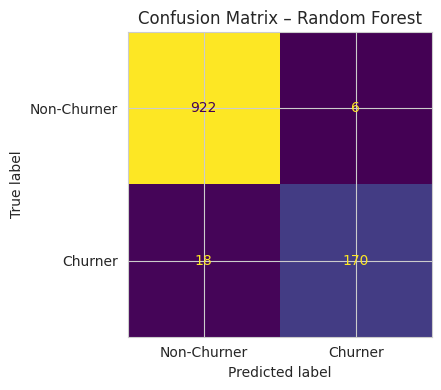

In [ ]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Non-Churner', 'Churner']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Non-Churner', 'Churner'], colorbar=False, ax=ax)
ax.set_title('Confusion Matrix – Random Forest')
plt.tight_layout()
plt.show()

### C4. Model Comparison & Lift Curve

In [ ]:
#  Model Comparison Summary
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score (Churner)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'Recall (Churner)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ]
}).round(4)
print(comparison.to_string(index=False))

              Model  F1-Score (Churner)  Recall (Churner)
Logistic Regression              0.5584            0.8138
      Random Forest              0.9341            0.9043


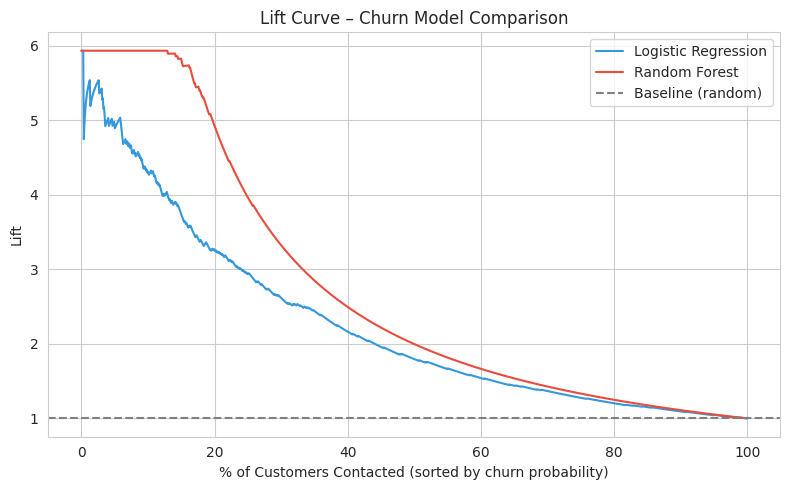

In [ ]:
# Lift Curve
def lift_curve(y_true, y_prob, model_name, ax, color):
    df_lift = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})
    df_lift = df_lift.sort_values('y_prob', ascending=False).reset_index(drop=True)
    df_lift['cumulative_churn'] = df_lift['y_true'].cumsum()
    df_lift['decile'] = (df_lift.index / len(df_lift) * 100)
    baseline = df_lift['y_true'].mean()
    df_lift['lift'] = (df_lift['cumulative_churn'] / (df_lift.index + 1)) / baseline
    ax.plot(df_lift['decile'], df_lift['lift'], label=model_name, color=color)

fig, ax = plt.subplots(figsize=(8, 5))
lift_curve(y_test, y_prob_lr, 'Logistic Regression', ax, '#3498db')
lift_curve(y_test, y_prob_rf, 'Random Forest', ax, '#e74c3c')
ax.axhline(y=1, color='grey', linestyle='--', label='Baseline (random)')
ax.set_title('Lift Curve – Churn Model Comparison')
ax.set_xlabel('% of Customers Contacted (sorted by churn probability)')
ax.set_ylabel('Lift')
ax.legend()
plt.tight_layout()
plt.show()

### C6. Feature Importance (Random Forest)

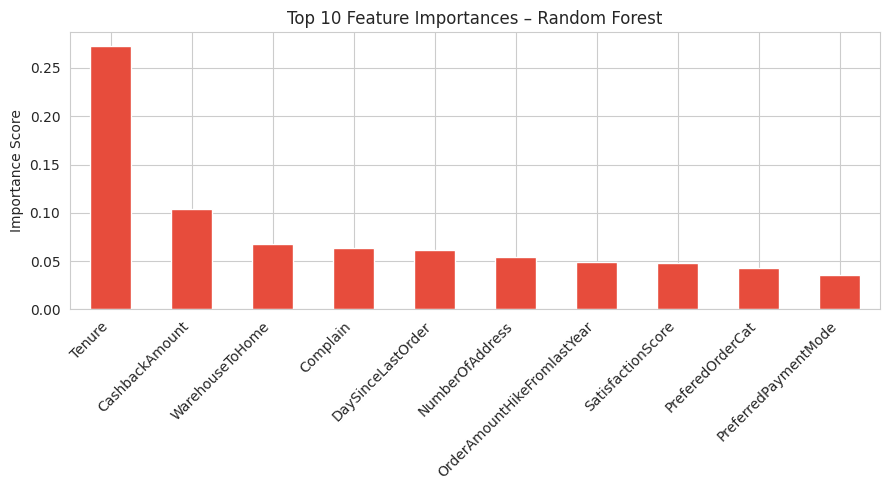

Top 3 churn risk drivers:
  1. Tenure: 0.2731
  2. CashbackAmount: 0.1044
  3. WarehouseToHome: 0.0677


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='#e74c3c')
plt.title('Top 10 Feature Importances – Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 3 churn risk drivers:')
for i, (feat, val) in enumerate(importances.head(3).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')